# ID 300155488
# etudiant : Iba Kane


🔍 Calcul du plus court chemin (a → e)...
✅ Chemin optimal : a → c → f → e
📏 Distance totale : 20


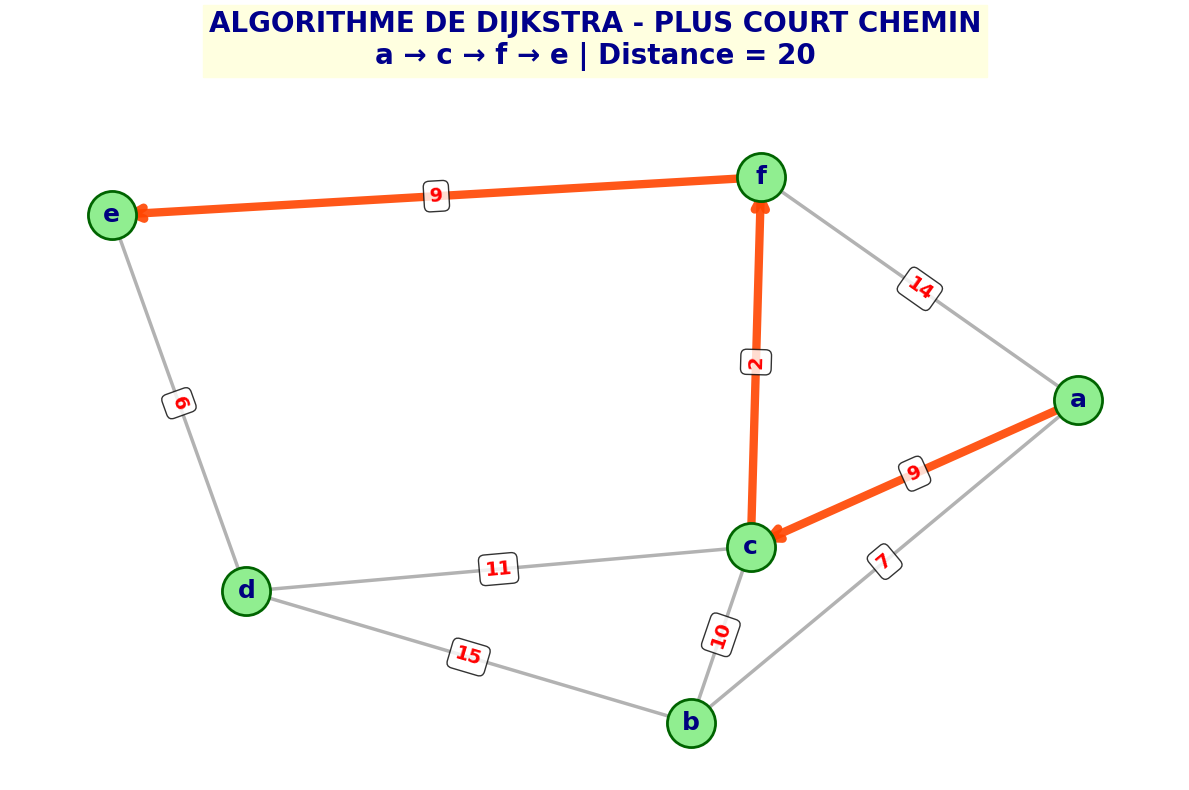

🖼️  SAUVEGARDÉ : images/rapport_dijkstra_300155488.png


In [15]:
from graph import Graph, Vertex
from dijkstra_tp import g, dijkstra, shortest
import networkx as nx
import matplotlib.pyplot as plt
import os
from io import StringIO
from contextlib import redirect_stdout

print("🔍 Calcul du plus court chemin (a → e)...")

# 1. DIJKSTRA SANS DEBUG MESSY
f = StringIO()
with redirect_stdout(f):
    for v in g:
        v.set_distance(float('inf'))
        v.visited = False
        v.previous = None
    start = g.get_vertex('a')
    target = g.get_vertex('e')
    dijkstra(g, start)

path = shortest(target)
distance = target.get_distance()

print(f"✅ Chemin optimal : {' → '.join(path)}")
print(f"📏 Distance totale : {distance}")

# 2. GRAPHE NETWORKX
G_nx = nx.Graph()
for v in g: G_nx.add_node(v.get_id())
for v in g:
    for w in v.get_connections():
        G_nx.add_edge(v.get_id(), w.get_id(), weight=v.get_weight(w))

# 3. DOSSIER + FIGURE PRO
#os.makedirs('images', exist_ok=True)
filename = 'images/rapport_dijkstra_300155488.png'

pos = nx.spring_layout(G_nx, seed=42)
plt.figure(figsize=(12,8))

path_edges = list(zip(path, path[1:]))
nx.draw_networkx_nodes(G_nx, pos, node_size=1200, node_color='#90EE90', edgecolors='darkgreen', linewidths=2)
nx.draw_networkx_edges(G_nx, pos, edgelist=[e for e in G_nx.edges() 
    if e not in path_edges and (e[1],e[0]) not in path_edges], width=2.5, edge_color='gray', alpha=0.6, style='solid')
nx.draw_networkx_edges(G_nx, pos, edgelist=path_edges, width=6, edge_color='#FF4500', alpha=0.9, arrows=True, arrowstyle='->', arrowsize=20)
nx.draw_networkx_labels(G_nx, pos, font_size=18, font_weight='bold', font_color='navy')
labels = {(u,v): str(d['weight']) for u,v,d in G_nx.edges(data=True)}
nx.draw_networkx_edge_labels(G_nx, pos, edge_labels=labels, font_color='red', font_size=14, font_weight='bold', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.title(f"ALGORITHME DE DIJKSTRA - PLUS COURT CHEMIN\n{''.join([f'{p} → ' for p in path[:-1]] + [path[-1]])} | Distance = {distance}", 
          fontsize=20, fontweight='bold', pad=40, color='darkblue', backgroundcolor='lightyellow')
plt.axis('off')
plt.tight_layout()

plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"🖼️  SAUVEGARDÉ : {filename}")

